In [25]:
import h5py as h5
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from photonlib import PhotonLib
file = "/sdf/data/neutrino/pubdata/lut/optical/waveform_map/batch02/consolidated/plib.h5"
plib = PhotonLib.load(file, True)
out_target = plib(torch.tensor([-1000, 0, 0]))
out_target = out_target.reshape(81, 1000)

[PhotonLib] loading /sdf/data/neutrino/pubdata/lut/optical/waveform_map/batch02/consolidated/plib.h5
[PhotonLib] loading lazily
[PhotonLib] file loaded


In [26]:
from slar.nets import Siren
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # heavy feature extractor
        # self.feature_net = Siren(
        #     in_features=1,
        #     out_features=512,
        #     hidden_features=512,
        #     hidden_layers=6,
        #     outermost_linear=True
        # )
        
        # branch for voltage output
        self.v_net = Siren(
            in_features=1,
            out_features=1,
            hidden_features=128,
            hidden_layers=2,
            outermost_linear=True
        )
        
        # branch for t0 and cdf outputs
        self.t0_cdf_net = Siren(
            in_features=1,
            out_features=1001,
            hidden_features=256,
            hidden_layers=3,
            outermost_linear=True
        )

    def forward(self, x):
        # out = self.net(x)
        # out = self.feature_net(x)
        out_v = self.v_net(x)
        out_t0cdf = self.t0_cdf_net(x)
        out_t0, out_cdf = out_t0cdf[:, :1], out_t0cdf[:, 1:]
        out_v = out_v
        out_t0 = torch.sigmoid(out_t0) * 1000  # t0 between 0 and 1000
        
        # create time indices
        time_indices = torch.arange(1000, device=x.device, dtype=torch.float32)[None, :]
        
        # create soft mask using sigmoid for smooth transition
        mask = torch.sigmoid((time_indices - out_t0) * 10)  # steepness factor of 10
        
        # normalize and cumsum only the valid part
        # out_cdf = out_cdf.softmax(-1).cumsum(-1)
        out_cdf = torch.logcumsumexp(out_cdf, dim=-1) - torch.logsumexp(out_cdf, dim=-1, keepdim=True)
        
        # apply soft mask to make cdf smoothly transition from zero before t0
        out_cdf = out_cdf * mask
        return out_v, out_cdf

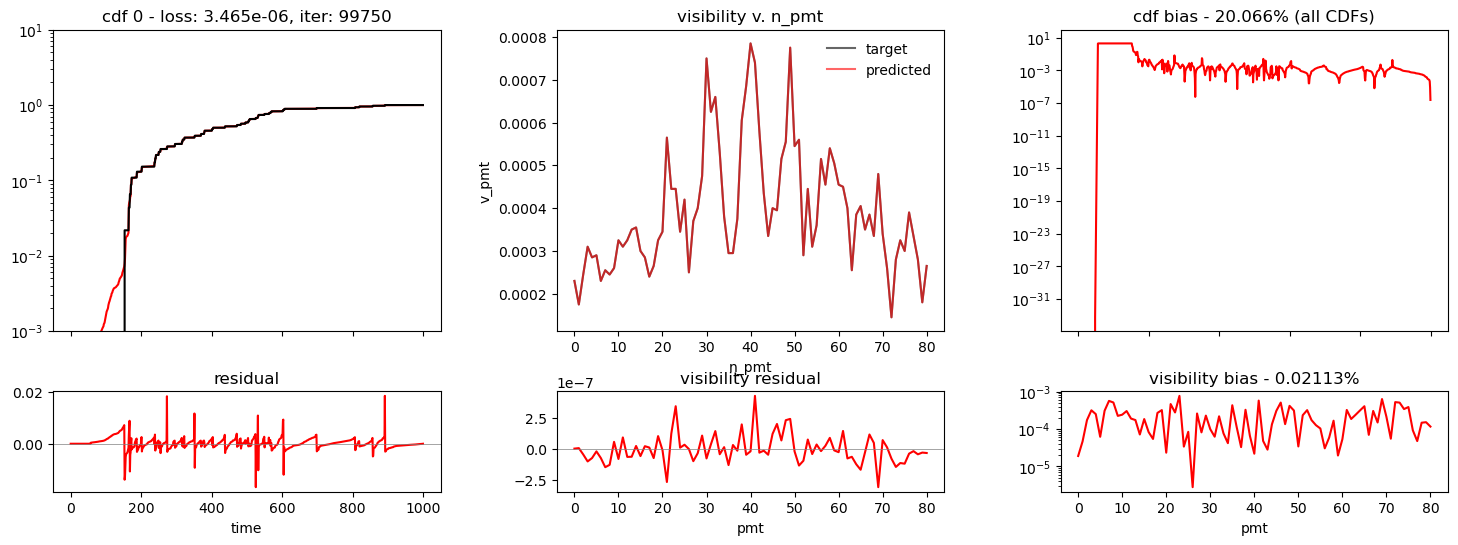

In [34]:
from slar.nets import Siren
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # branch for voltage output
        self.v_net = Siren(
            in_features=1,
            out_features=1,
            hidden_features=128,
            hidden_layers=2,
            outermost_linear=True
        )
        
        # branch for t0 and cdf outputs
        self.t0_cdf_net = Siren(
            in_features=1,
            out_features=1001,
            hidden_features=256,
            hidden_layers=3,
            outermost_linear=True
        )

    def forward(self, x):
        out_v = self.v_net(x)
        out_t0cdf = self.t0_cdf_net(x)
        out_t0, out_cdf = out_t0cdf[:, :1], out_t0cdf[:, 1:]
        out_v = out_v - 8 # <-- initalize guess with 1e-8 offset
        out_t0 = torch.sigmoid(out_t0) * 1000  # t0 between 0 and 1000
        
        # create time indices
        time_indices = torch.arange(1000, device=x.device, dtype=torch.float32)[None, :]
        
        # create soft mask using sigmoid for smooth transition
        mask = torch.sigmoid((time_indices - out_t0) * 10)  # steepness factor of 10
        
        # normalize and cumsum only the valid part
        out_cdf = out_cdf.softmax(-1).cumsum(-1)
        
        # apply soft mask to make cdf smoothly transition from zero before t0
        out_cdf = out_cdf * mask
        
        return out_v, out_cdf
        
from IPython.display import clear_output
import matplotlib.pyplot as plt
import torch.nn.functional as F

device = 'cuda:0'
net = Net().to(device)

pmt_id = torch.linspace(-1,1,81).to(device)[:,None]
optim = torch.optim.Adam(net.parameters(), lr=1e-4)
# TARGET
n = torch.log(out_target.sum(-1, keepdim=True).to(device))
wvfm = F.normalize(out_target, p=1, dim=-1).cumsum(-1).to(device)

losses = []
for i in range(100000):
    optim.zero_grad()
    out_v, out_cdf = net(pmt_id)
    losses = []

    losses += [F.smooth_l1_loss(out_cdf, wvfm)]
    losses += [F.smooth_l1_loss(out_v, n)]
    loss = torch.stack(losses).sum()  # geometric mean

    loss.backward()
    optim.step()
    losses.append(loss.item())
    clear_output(wait=True)
    if i % 250 == 0:
        fig, ((ax1, ax3, ax5), (ax2, ax4, ax6)) = plt.subplots(2, 3, figsize=(18, 6), gridspec_kw={'height_ratios': [3, 1]})
        
        # main plot
        for o in out_cdf.detach().cpu():
            ax1.plot(o, alpha=1., color='red', label='predicted')
            break
        for o in wvfm.detach().cpu():
            ax1.plot(o, alpha=1., color='black', label='target')
            break
        ax1.set_title(f'cdf 0 - loss: {loss.item():.3e}, iter: {i}')
        ax1.semilogy()
        ax1.set_ylim(1e-3, 1e1)
        ax1.set_xticklabels([])
        
        # residual plot
        residual = (out_cdf.detach().cpu()[0] - wvfm.detach().cpu()[0])
        ax2.plot(residual, color='red')
        ax2.axhline(0, color='grey', linewidth=0.5)
        # get ymin and ymax
        ymin, ymax = ax2.get_ylim()
        max_val = max(abs(ymin), ymax)
        # ax2.set_ylim(-0.1, 0.1)
        ax2.set_title('residual')
        ax2.set_xlabel('time')
        
        # out_v vs n plot
        ax3.plot(n.detach().cpu().exp(), alpha=0.6, color='black', label='target')
        ax3.plot(out_v.detach().cpu().exp(), alpha=0.6, color='red', label='predicted')
        # ax3.plot([n.exp().min().item(), n.exp().max().item()], [n.exp().min().item(), n.exp().max().item()], 'r--', alpha=0.8)
        ax3.set_xlabel('n_pmt')
        ax3.set_ylabel('v_pmt')
        ax3.set_title('visibility v. n_pmt')
        ax3.legend(frameon=False)

        # visibility residual plot
        v_residual = (out_v.detach().cpu().exp() - n.detach().cpu().exp()).flatten()
        ax4.plot(v_residual, color='red')
        ax4.axhline(0, color='grey', linewidth=0.5)
        ax4.set_title('visibility residual')
        ax4.set_xlabel('pmt')
        
        # cdf bias plot
        cdf_true = wvfm.detach().cpu()[0]
        cdf_pred = out_cdf.detach().cpu()[0]
        cdf_bias = 2 * torch.abs(cdf_true - cdf_pred) / (cdf_true + cdf_pred + 1e-8)
        ax5.plot(cdf_bias, color='red')
        ax5.set_title(f'cdf bias - {cdf_bias.mean().item():.3%} (all CDFs)')
        ax5.set_yscale("log")
        ax5.set_xticklabels([])
        
        # visibility bias plot
        v_true = n.detach().cpu().exp().flatten()
        v_pred = out_v.detach().cpu().exp().flatten()
        v_bias = 2 * torch.abs(v_true - v_pred) / (v_true + v_pred + 1e-8)
        ax6.plot(v_bias, color='red')
        ax6.set_title(f'visibility bias - {v_bias.mean().item():.5%}')
        ax6.set_xlabel('pmt')
        ax6.set_yscale("log")
        
        plt.subplots_adjust(hspace=0.3, wspace=0.3)
        plt.show()